# Week 5 — Exponential Smoothing & ETS Models

Exponential smoothing methods weight recent observations more heavily. This notebook covers Simple Exponential Smoothing, Holt's method, and Holt-Winters.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 5.1 Simple Exponential Smoothing (SES)

$$\hat{y}_{t+1|t} = \alpha y_t + (1-\alpha) \hat{y}_{t|t-1}$$

The smoothing parameter $\alpha \in [0,1]$ controls how quickly we forget the past.

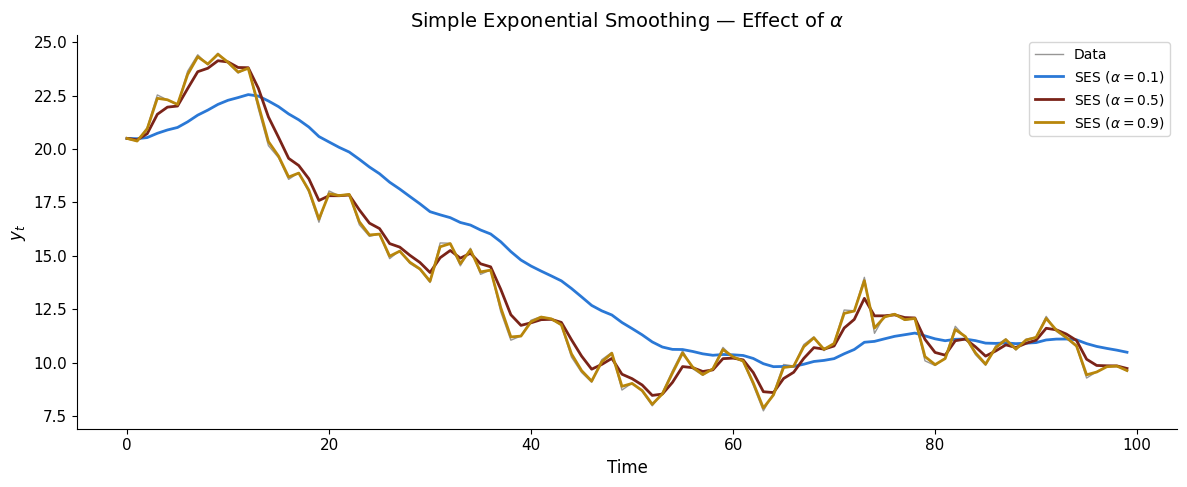

In [2]:
np.random.seed(42)
T = 100
y = np.cumsum(np.random.normal(0, 1, T)) + 20  # random walk with drift

alphas = [0.1, 0.5, 0.9]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y, color=UOE_GREY, lw=1, alpha=0.6, label='Data')

for alpha, col in zip(alphas, [UOE_BLUE, UOE_RED, UOE_GOLD]):
    smooth = np.zeros(T)
    smooth[0] = y[0]
    for t in range(1, T):
        smooth[t] = alpha * y[t] + (1 - alpha) * smooth[t-1]
    ax.plot(smooth, color=col, lw=2, label=f'SES ($\\alpha = {alpha}$)')

ax.set_xlabel('Time')
ax.set_ylabel('$y_t$')
ax.set_title('Simple Exponential Smoothing — Effect of $\\alpha$')
ax.legend()
plt.tight_layout()
plt.show()


## 5.2 Holt's Linear Trend Method

Adds a trend component:
$$\ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1} + b_{t-1})$$
$$b_t = \beta^* (\ell_t - \ell_{t-1}) + (1-\beta^*) b_{t-1}$$

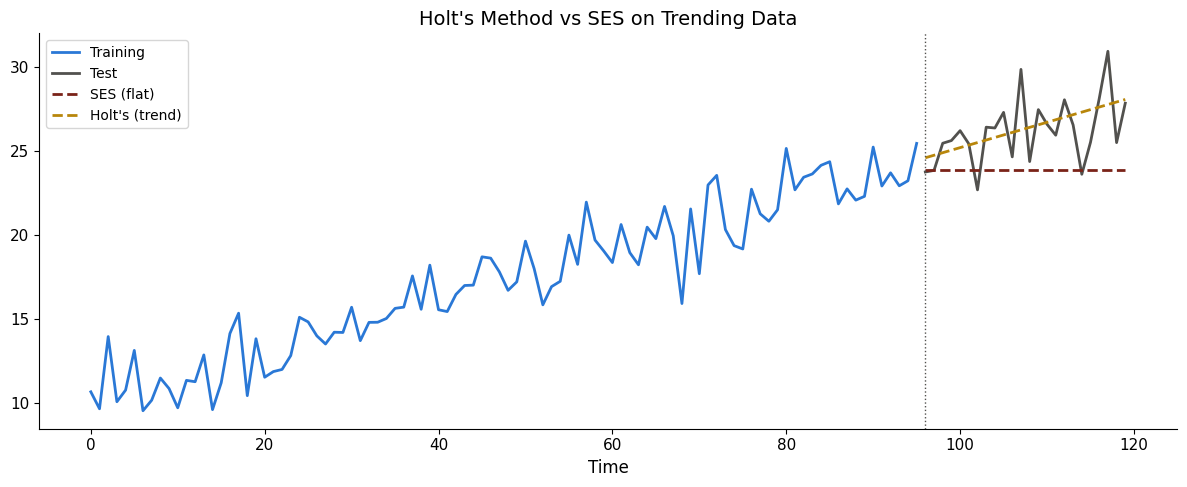

In [3]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.random.seed(5)
T = 120
t = np.arange(T)
y_trend = 10 + 0.15 * t + np.random.normal(0, 1.5, T)

train, test = y_trend[:96], y_trend[96:]

# Fit Holt's method
model_holt = ExponentialSmoothing(train, trend='add', seasonal=None).fit()
fc_holt = model_holt.forecast(steps=len(test))

# Compare with SES
model_ses = ExponentialSmoothing(train, trend=None, seasonal=None).fit()
fc_ses = model_ses.forecast(steps=len(test))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(96), train, color=UOE_BLUE, label='Training')
ax.plot(range(96, 120), test, color=UOE_GREY, lw=2, label='Test')
ax.plot(range(96, 120), fc_ses, '--', color=UOE_RED, lw=2, label='SES (flat)')
ax.plot(range(96, 120), fc_holt, '--', color=UOE_GOLD, lw=2, label="Holt's (trend)")
ax.axvline(96, ls=':', color=UOE_GREY, lw=1)
ax.set_title("Holt's Method vs SES on Trending Data")
ax.set_xlabel('Time')
ax.legend()
plt.tight_layout()
plt.show()


## 5.3 Holt-Winters: Adding Seasonality

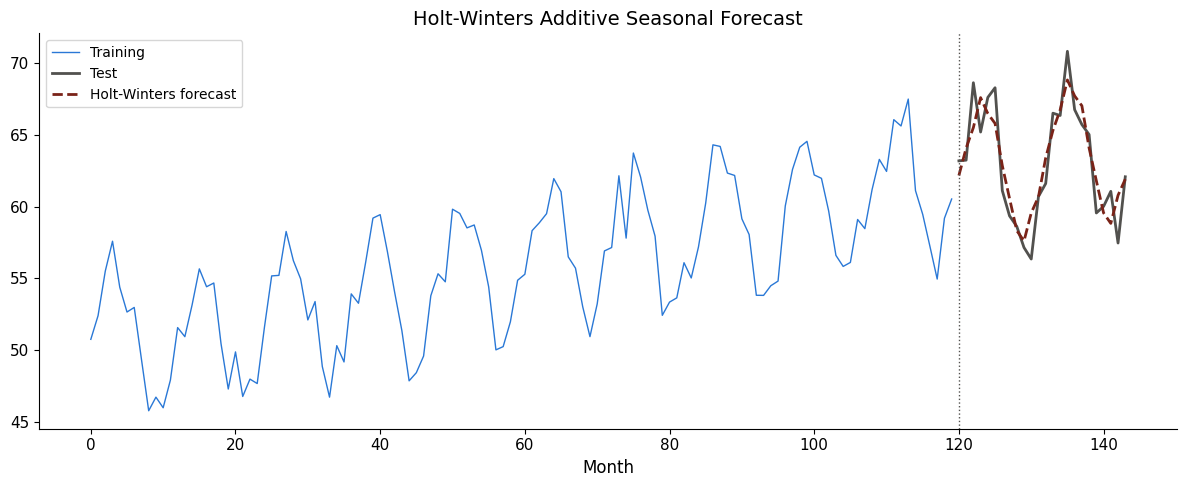

Holt-Winters RMSE: 1.750


In [4]:
np.random.seed(42)
T = 144  # 12 years of monthly
t = np.arange(T)
y_hw = 50 + 0.1 * t + 5 * np.sin(2 * np.pi * t / 12) + np.random.normal(0, 1.5, T)

train_hw, test_hw = y_hw[:120], y_hw[120:]

model_hw = ExponentialSmoothing(train_hw, trend='add',
                                 seasonal='add', seasonal_periods=12).fit()
fc_hw = model_hw.forecast(steps=24)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(120), train_hw, color=UOE_BLUE, lw=1, label='Training')
ax.plot(range(120, 144), test_hw, color=UOE_GREY, lw=2, label='Test')
ax.plot(range(120, 144), fc_hw, '--', color=UOE_RED, lw=2, label='Holt-Winters forecast')
ax.axvline(120, ls=':', color=UOE_GREY, lw=1)
ax.set_title('Holt-Winters Additive Seasonal Forecast')
ax.set_xlabel('Month')
ax.legend()
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((test_hw - fc_hw)**2))
print(f"Holt-Winters RMSE: {rmse:.3f}")


## 5.4 Decomposition: Trend + Seasonal + Residual

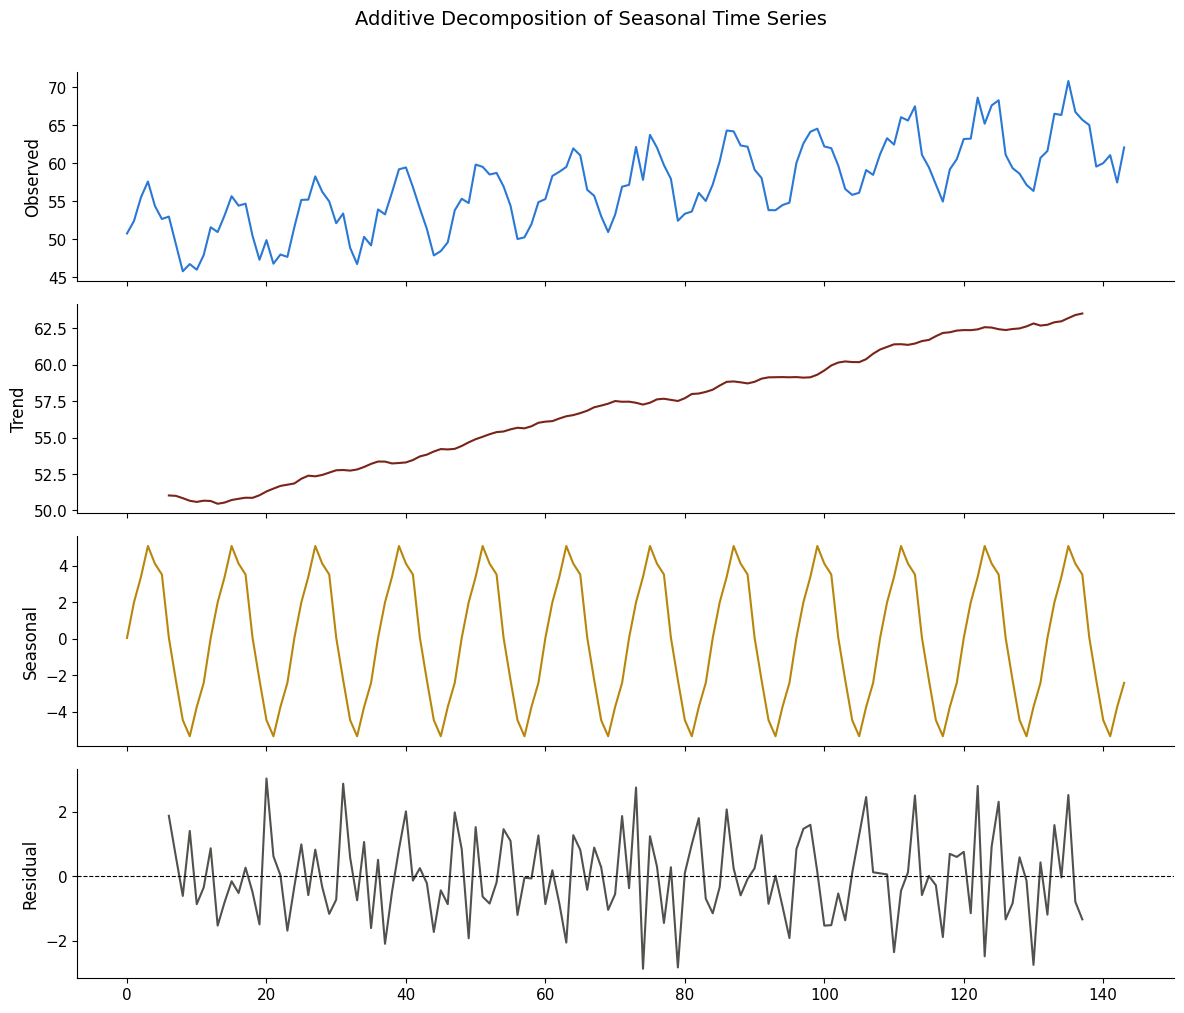

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(y_hw, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
components = [('Observed', decomp.observed, UOE_BLUE),
              ('Trend', decomp.trend, UOE_RED),
              ('Seasonal', decomp.seasonal, UOE_GOLD),
              ('Residual', decomp.resid, UOE_GREY)]

for ax, (name, comp, col) in zip(axes, components):
    ax.plot(comp, color=col, lw=1.5)
    ax.set_ylabel(name)
    if name == 'Residual':
        ax.axhline(0, ls='--', color='k', lw=0.8)

plt.suptitle('Additive Decomposition of Seasonal Time Series', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Exercises

<details><summary>Exercise 1: Compare multiplicative vs additive Holt-Winters on data with growing amplitude.</summary>

```python
t = np.arange(144)
y = 50 + 0.2*t + (1 + 0.03*t) * 5 * np.sin(2*np.pi*t/12) + np.random.normal(0, 1, 144)
for seasonal in ['add', 'mul']:
    m = ExponentialSmoothing(y[:120], trend='add', seasonal=seasonal, seasonal_periods=12).fit()
    fc = m.forecast(24)
    rmse = np.sqrt(np.mean((y[120:] - fc)**2))
    print(f'{seasonal}: RMSE = {rmse:.3f}')
```
</details>